# L4b Advanced: First-Passage Rules Under Geometric Brownian Motion

In [the L4b lecture](../../CHEME-5660-L4b-Lecture-SingleAsset-GeometricBrownianMotion-TradeRule-Fall-2026.ipynb), we used geometric Brownian motion (GBM) to calculate the probability that a long stock position exceeds a target scaled NPV at a scheduled sale time $T$. What changes if we monitor the price during the holding period and sell when it reaches a take-profit or stop-loss boundary?

The [L4a first-passage example](../../../L4a/advanced/first-passage/CHEME-5660-L4a-Advanced-FirstPassage-ExitRules-Fall-2026.ipynb) answered this question using a binomial lattice. A price path can reach an exit boundary and later finish back between the boundaries, so the final price alone does not tell us whether an earlier exit occurred. We call the first time the price reaches an exit boundary its *first-passage time*.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Compare reaching with finishing:** Calculate the probability that a GBM price reaches a take-profit level by the end of the holding period, and explain why this exceeds the probability of finishing above the same level.
> * **Evaluate two-barrier exit rules:** Compute the probabilities of reaching the take-profit first, reaching the stop-loss first, or reaching neither by time $T$, using a GBM-calibrated lattice and Monte Carlo under the same monitoring schedule.
> * **Assess the effect of monitoring frequency:** Examine how the gap between discrete and continuous single-barrier probabilities changes with the monitoring interval, and evaluate a shifted-barrier approximation to the discrete probability.

In this example, we extend the L4a first-passage calculation to geometric Brownian motion. We use a closed-form result for one continuously monitored barrier, compare lattice and Monte Carlo results for two barriers checked daily, and then vary the monitoring frequency to examine how it changes the probability of detecting an exit.

Let's get started!

___


## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used here.

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load packages and the documented functions in src/

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/), [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/), [Distributions.jl documentation](https://juliastats.org/Distributions.jl/stable/), [Plots.jl documentation](https://docs.juliaplots.org/stable/), and [PrettyTables.jl documentation](https://ronisbr.github.io/PrettyTables.jl/stable/) for the functions and types used here.

We use the lecture's constant-parameter GBM in log-price form and the GBM-calibrated binomial lattice developed in [the lattice-limit example](../lattice-limit/CHEME-5660-L4b-Advanced-LatticeToGBM-Fall-2026.ipynb). The first-passage functions and their Julia docstrings are in the local [src directory](src), loaded by [Include.jl](Include.jl).

Let's set the plotting defaults:


In [2]:
# Set shared figure defaults -
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
    left_margin = 6Plots.mm, # leave room for axis labels
    bottom_margin = 6Plots.mm,
);

___

## Task 1: Calculate the Probability of Reaching the Take-Profit Price

In this task, we calculate the probability that the stock price reaches a take-profit level during the holding period and compare it with the probability of finishing above that level at time $T$.

### Log-price model and exit boundaries

Recall from the lecture that the GBM solution can be written in terms of the log price ratio:

$$
X_t=\ln\!\left(\frac{S_t}{S_0}\right)=\mu_g t+\sigma W(t),
\qquad \mu_g=\mu-\frac{\sigma^2}{2}.
$$

Here, $S_0>0$ is the initial share price, $\mu$ is the arithmetic drift, $\mu_g$ is the mean growth rate, $\sigma>0$ is the volatility, and $W(t)$ is a standard Wiener process. We assume constant drift and volatility over the holding period $T>0$. With time measured in years, $\mu$ and $\mu_g$ have units of year$^{-1}$, and $\sigma$ has units of year$^{-1/2}$.

Suppose the take-profit level is $U>S_0$ and the stop-loss level is $L<S_0$, with both prices positive. The corresponding boundaries for the log price ratio are given by:

$$
b=\ln\!\left(\frac{U}{S_0}\right)>0,
\qquad
a=\ln\!\left(\frac{L}{S_0}\right)<0.
$$

Because the logarithm is increasing, reaching $U$ in the share price is equivalent to reaching $b$ in the log price ratio; the same relationship holds for $L$ and $a$. We first consider the upper boundary under continuous monitoring. Task 2 will consider both exit boundaries together.

### Probability of finishing above the take-profit price

Suppose we wait until time $T$ to sell. The log price ratio $X_T$ is normally distributed with mean $\mu_g T$ and standard deviation $\sigma\sqrt{T}$. Subtracting this mean and dividing by the standard deviation gives the standard normal random variable:

$$
Z=\frac{X_T-\mu_g T}{\sigma\sqrt{T}}\sim\mathcal N(0,1).
$$

The share price finishes at or above $U$ when $X_T\geq b$. Applying the same standardization to this inequality gives:

$$
\begin{aligned}
\mathbb P(S_T\geq U)
&=\mathbb P(X_T\geq b)\\[4pt]
&=\mathbb P\!\left(Z\geq\frac{b-\mu_g T}{\sigma\sqrt{T}}\right)\\[4pt]
&=1-\Phi\!\left(\frac{b-\mu_g T}{\sigma\sqrt{T}}\right),
\end{aligned}
$$

where $\Phi$ is the standard normal cumulative distribution function. This calculation uses only the price at time $T$.

### Probability of reaching the take-profit price

Now suppose we monitor the price continuously and sell as soon as it reaches $U$. The stock may later fall below $U$ even though the sale has already occurred. To include these earlier exits, we consider the largest log price ratio reached during the holding period:

$$
M_T=\max_{0\leq s\leq T}X_s.
$$

The price reaches $U$ by time $T$ exactly when $M_T\geq b$. Every path that finishes at or above $U$ must have reached it, because GBM price paths are continuous. Other paths reach $U$ and finish below it. These two groups account for all paths that reach the take-profit price.

For Brownian motion with drift, the [reflection-principle result](https://www.columbia.edu/~sk75/mfBGK.pdf#page=16) gives their combined probability:

$$
\mathbb P(M_T\geq b)
=\underbrace{\Phi\!\left(\frac{\mu_g T-b}{\sigma\sqrt{T}}\right)}_{\text{finish at or above }U}
+\underbrace{e^{2\mu_g b/\sigma^2}\,\Phi\!\left(\frac{-\mu_g T-b}{\sigma\sqrt{T}}\right)}_{\text{reach }U\text{ and finish below }U}.
$$

The first term equals the scheduled-sale probability above because $\Phi(-z)=1-\Phi(z)$. The second term accounts for earlier take-profit exits that a check of the final price would miss. This is why reaching the take-profit price is more likely than finishing above it.

__Constants.__ Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units. We use a quarter-year holding period and a take-profit price 10% above the initial price. The 8% stop-loss is used in Task 2.


In [3]:
S₀ = 100.0      # initial share price (USD/share)
μ = 0.15        # arithmetic GBM drift (1/years)
σ = 0.30        # GBM volatility (1/sqrt(years))
T = 0.25        # horizon (years), about one trading quarter
U = 110.0       # take-profit level (USD/share)
L = 92.0        # stop-loss level (USD/share)
μ_g = μ - 0.5*σ^2 # mean growth rate (1/years)
b = log(U/S₀)   # dimensionless upper log-price boundary
a = log(L/S₀)   # dimensionless lower log-price boundary

@assert L < S₀ < U && σ > 0 && T > 0 # ordered boundaries and positive volatility/horizon
(S₀ = S₀, μ = μ, σ = σ, T = T, U = U, L = L, μ_g = μ_g, b = b, a = a)

(S₀ = 100.0, μ = 0.15, σ = 0.3, T = 0.25, U = 110.0, L = 92.0, μ_g = 0.105, b = 0.09531017980432493, a = -0.08338160893905101)

Let's calculate the two probabilities. [The terminal_above(...) function](src/Probabilities.jl) calculates the probability that the price finishes at or above $U$, and [the reach_upper(...) function](src/Probabilities.jl) calculates the probability of reaching $U$ by time $T$ under continuous monitoring. Both use the log-price boundary $b=\ln(U/S_0)$. We store their results in `p_finish` and `p_reach`, respectively:


In [4]:
p_finish = terminal_above(b, μ_g, σ, T) # final-price check only
p_reach = reach_upper(b, μ_g, σ, T)     # continuous checks throughout the holding period
println("Finish above U = $(U):  P(S_T ≥ U)            = $(round(p_finish, digits = 4))")
println("Reach U before T:      P(max S_t ≥ U, t ≤ T) = $(round(p_reach, digits = 4))")
println("Touched U but finished below it:              $(round(p_reach - p_finish, digits = 4))")
@assert p_reach >= p_finish # finishing above the target implies having reached it

Finish above U = 110.0:  P(S_T ≥ U)            = 0.3226


Reach U before T:      P(max S_t ≥ U, t ≤ T) = 0.5835
Touched U but finished below it:              0.2609


With the illustrative parameters above, the probability of reaching the take-profit price is about 58.35%, compared with 32.26% for finishing at or above it. The difference, about 26.09 percentage points, accounts for paths that reach the take-profit price and then finish below it. These values will change if we change the model parameters or take-profit price.

Let's now vary the take-profit price from 101 to 130 USD/share while keeping the initial price, drift, volatility, and holding period fixed. We plot both probabilities and their difference:


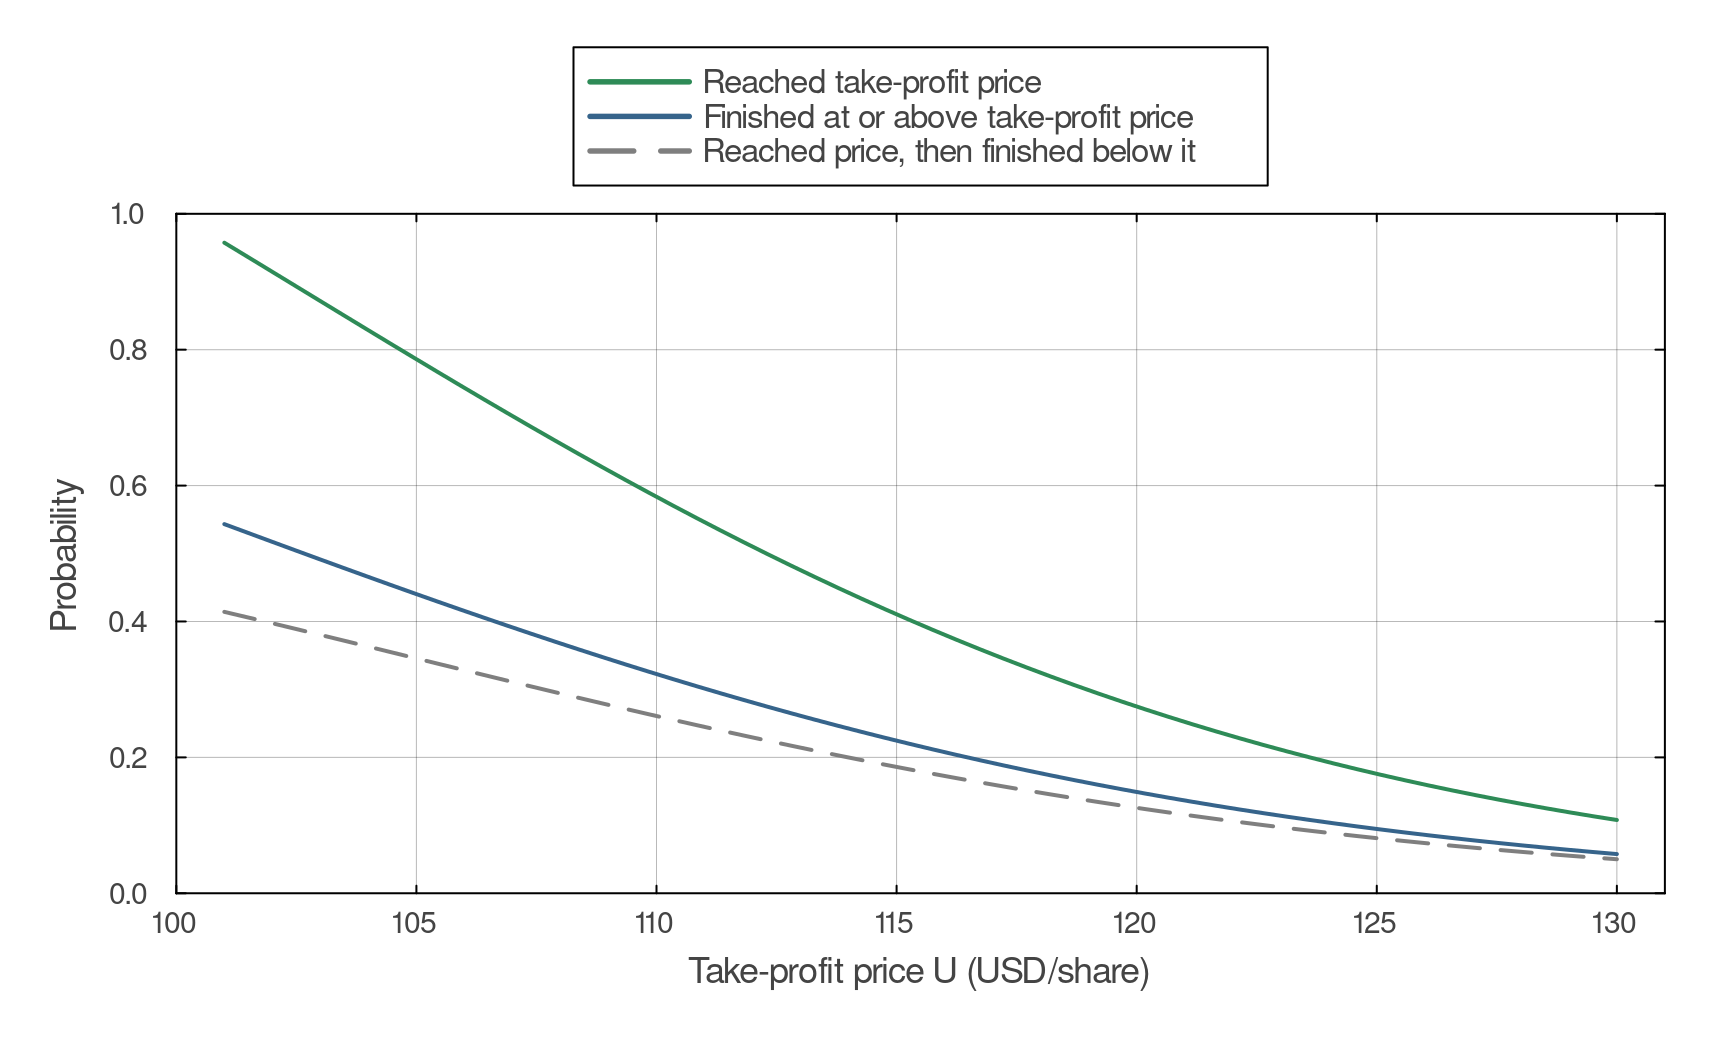

In [5]:
let
    # Vary the take-profit price while holding the GBM parameters fixed -
    U_grid = range(101.0, 130.0, length = 60) # candidate prices, USD/share
    finish = [terminal_above(log(u/S₀), μ_g, σ, T) for u ∈ U_grid]
    reach = [reach_upper(log(u/S₀), μ_g, σ, T) for u ∈ U_grid]
    # Display both probabilities and the probability of reaching then falling below -
    plot(U_grid, reach; color = :seagreen4, label = "Reached take-profit price",
        xlabel = "Take-profit price U (USD/share)", ylabel = "Probability",
        size = (860, 520), dpi = 200, legend = :outertop,
        legendfontsize = 11, guidefontsize = 12, tickfontsize = 10,
        background_color = :white, gridalpha = 0.15,
        xlims = (100, 131), xticks = 100:5:130,
        ylims = (0, 1), yticks = 0:0.2:1,
        left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 5Plots.mm, top_margin = 4Plots.mm)
    plot!(U_grid, finish; color = :steelblue4,
        label = "Finished at or above take-profit price")
    plot!(U_grid, reach .- finish; color = :gray50, linestyle = :dash,
        label = "Reached price, then finished below it")
end

Both probabilities decrease as the take-profit price rises: a higher price is harder to reach and harder to exceed at time $T$. For these parameters, a target close to the initial price is reached by nearly all paths, while substantially fewer finish above it. The dashed curve gives the probability of reaching the take-profit price and then finishing below it; this gap narrows as the target increases over the plotted range.

Let's now add a stop-loss and calculate which exit price is reached first.

___

## Task 2: Calculate Take-Profit and Stop-Loss Probabilities

In this task, we calculate the probabilities of a take-profit sale, a stop-loss sale, and still holding the shares at time $T$.

We check the price at the end of each of the quarter's 63 trading days. We sell at the first check with price at or above $U$, or at or below $L$; otherwise, we continue holding. A crossing between checks does not trigger a sale unless an exit condition also holds at a check.

Every path has exactly one outcome, so the probabilities satisfy:

$$
\mathbb P(\text{take-profit first})
+\mathbb P(\text{stop-loss first})
+\mathbb P(\text{still holding at }T)=1.
$$

Let's calculate these probabilities using a binomial lattice and compare them with Monte Carlo estimates under the same daily monitoring schedule.

### Build a lattice with daily price checks

For $N$ lattice steps over the holding period, each step lasts $\Delta t=T/N$. Using the calibration developed in [the lattice-limit example](../lattice-limit/CHEME-5660-L4b-Advanced-LatticeToGBM-Fall-2026.ipynb), the up factor, down factor, and up probability are given by:

$$
u=e^{\sigma\sqrt{\Delta t}},\qquad
d=\frac{1}{u},\qquad
p=\frac{1}{2}\left(1+\frac{\mu_g}{\sigma}\sqrt{\Delta t}\right).
$$

These choices match the mean log return per step; the variance approaches the GBM value as the step length decreases. [The lattice_from_gbm(...) function](src/Lattice.jl) checks that $0<p<1$; if this fails, we need a smaller time step.

We use 64 lattice steps per trading day to improve price resolution, but check the exit conditions only once per day. With `N_fine = 63*64` and `check_every = 64`, the time between checks is:

$$
64\Delta t=64\frac{T}{63\times64}=\frac{T}{63}.
$$

For $T=0.25$ years, this is one trading day under our 252-day convention. Setting `check_every = 1` instead checks every fine step, approximating continuous monitoring on the same price lattice.

### Track positions that are still open

As in [the L4a first-passage calculation](../../../L4a/advanced/first-passage/CHEME-5660-L4a-Advanced-FirstPassage-ExitRules-Fall-2026.ipynb), we carry forward only the probabilities of unsold positions. At step $j$, a node with $k$ up moves has price:

$$
S_{j,k}=S_0u^kd^{j-k},\qquad k=0,1,\ldots,j.
$$

Initially, the position is open with probability one at $S_0$. At each step:

1. A node with open-position probability $w$ sends $pw$ to its up branch and $(1-p)w$ to its down branch. Contributions reaching the same node are added.
2. On a monitoring step, contributions at or below $L$ become stop-loss exits; those at or above $U$ become take-profit exits. We remove them from the open positions.
3. We carry forward the remaining contributions. Between checks, all contributions remain open, including those beyond an exit boundary.

After the final check, the remaining open probability gives the chance of still holding the shares. Let's use [the first_passage_lattice(...) function](src/Lattice.jl) to calculate the three outcomes with daily checks:


In [6]:
N_fine = 63*64 # 64 grid steps per trading day over a quarter
first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 64) # fine price grid, daily monitoring

(take_profit_first = 0.47807398981556165, stop_loss_first = 0.4406751434126383, still_open = 0.08125086677180175)

### Estimate the probabilities by simulating daily prices

For comparison, let's simulate prices from the GBM transition distribution. With daily interval $\Delta t_{\mathrm{day}}=T/63$ and $t_j=j\Delta t_{\mathrm{day}}$, the exact update is given by:

$$
S_{t_{j+1}}=S_{t_j}\exp\!\left(
\mu_g\Delta t_{\mathrm{day}}
+\sigma\sqrt{\Delta t_{\mathrm{day}}}\,Z_j
\right),
\qquad Z_j\sim\mathcal N(0,1),
$$

where the standard normal draws are independent across days and paths. The simulated prices can take any positive value, while the lattice restricts prices to its nodes. Both methods check the exit conditions on the same 63 daily dates.

We stop each path at its first detected sale; a path without a sale by $T$ is still open. If an outcome occurs $K$ times among $M$ independent paths, its estimated probability and standard error are given by:

$$
\hat q=\frac{K}{M},
\qquad
\operatorname{SE}(\hat q)
=\sqrt{\frac{\hat q(1-\hat q)}{M}}.
$$

The standard error estimates uncertainty from using finitely many paths; a smaller value indicates greater precision for the chosen model and monitoring schedule. [The monte_carlo_first_passage(...) function](src/Simulation.jl) returns these estimates for all three outcomes. Let's use 100,000 paths with a fixed random seed:


In [7]:
# Use 63 daily checks; helper defaults are 100,000 paths and seed 5660 -
mc_daily = monte_carlo_first_passage(S₀, μ, σ, T, 63; lower = L, upper = U)

(probability = (take_profit_first = 0.48394, stop_loss_first = 0.43593, still_open = 0.08013), standard_error = (take_profit_first = 0.001580322993568087, stop_loss_first = 0.0015681040625545233, still_open = 0.0008585405237960524))

### Compare the calculated exit probabilities

Each row of `two_barrier_table` describes one outcome. We compare the methods and monitoring schedules through these columns:

* `lat_daily` and `mc_daily` use the same daily checks; `mc_se` gives the simulation's standard error.
* `lat_cont` checks the fine lattice 64 times per trading day, approximating continuous monitoring.
* `coarse63` uses one lattice step and one check per day. Its up and down moves are about 2% for these parameters, giving a coarser set of possible prices.

Let's collect the results:


In [8]:
two_barrier_table = let
    # Compare price resolution and monitoring frequency -
    lat_daily = first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 64) # fine grid, daily checks
    lat_cont = first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 1)   # fine grid, every step
    lat_coarse = first_passage_lattice(S₀, μ, σ, T, 63; lower = L, upper = U)                       # 63-step lattice
    # Align the three outcomes across methods; mc_se measures sampling uncertainty -
    DataFrame(
        outcome = ["Take profit first", "Stop loss first", "Still open at T"],
        lat_daily = [lat_daily.take_profit_first, lat_daily.stop_loss_first, lat_daily.still_open],
        mc_daily = [mc_daily.probability.take_profit_first, mc_daily.probability.stop_loss_first, mc_daily.probability.still_open],
        mc_se = [mc_daily.standard_error.take_profit_first, mc_daily.standard_error.stop_loss_first, mc_daily.standard_error.still_open],
        lat_cont = [lat_cont.take_profit_first, lat_cont.stop_loss_first, lat_cont.still_open],
        coarse63 = [lat_coarse.take_profit_first, lat_coarse.stop_loss_first, lat_coarse.still_open],
    )
end
pretty_table(two_barrier_table; formatters = [fmt__printf("%.4f", [2,3,4,5,6])])

┌───────────────────┬───────────┬──────────┬─────────┬──────────┬──────────┐
│           outcome │ lat_daily │ mc_daily │   mc_se │ lat_cont │ coarse63 │
│            String │   Float64 │  Float64 │ Float64 │  Float64 │  Float64 │
├───────────────────┼───────────┼──────────┼─────────┼──────────┼──────────┤
│ Take profit first │    0.4781 │   0.4839 │  0.0016 │   0.4962 │   0.4621 │
│   Stop loss first │    0.4407 │   0.4359 │  0.0016 │   0.4600 │   0.4455 │
│   Still open at T │    0.0813 │   0.0801 │  0.0009 │   0.0438 │   0.0925 │
└───────────────────┴───────────┴──────────┴─────────┴──────────┴──────────┘


The daily take-profit probabilities differ by about 0.59 percentage points, or 3.7 Monte Carlo standard errors. Thus, although the estimates are close in absolute terms, the lattice approximation matters; more simulated paths alone will not remove the difference. The coarse lattice further restricts possible prices, and its first node beyond a boundary may lie farther from that boundary.

For these parameters, more frequent checks increase both exit probabilities and reduce the still-open probability. Adding observation times cannot increase the chance of still holding the shares, but either individual exit probability can decrease: an earlier stop-loss can prevent a later take-profit sale, or vice versa.

### Check the result over a longer holding period

With continuous monitoring and no final sale date, the price eventually reaches one boundary. Writing $\theta=2\mu_g/\sigma^2$, the probability of reaching the take-profit boundary first is given by:

$$
p_{\mathrm{TP},\infty}=
\begin{cases}
\displaystyle\frac{1-e^{-\theta a}}{e^{-\theta b}-e^{-\theta a}}, & \mu_g\ne0,\\[8pt]
\displaystyle\frac{-a}{b-a}, & \mu_g=0.
\end{cases}
$$

At zero mean growth, this depends only on the distances to the two log-price boundaries. Let's compare this continuous-monitoring result with a three-year lattice calculation, including the probability still open. Any difference can reflect the finite horizon, discrete checks, and lattice price resolution:


In [9]:
let
    θ = 2μ_g/σ^2 # dimensionless coefficient in the continuous exit formula
    # Use the zero-growth limit; expm1 avoids cancellation near zero -
    p_tp_infinite = iszero(θ) ? -a/(b-a) : expm1(θ*a)/expm1(-θ*(b-a)) # P(hit b before a), infinite horizon, continuous monitoring
    long = first_passage_lattice(S₀, μ, σ, 3.0, 3*252*16; lower = L, upper = U) # three years, 16 checks per day
    println("Infinite-horizon closed form: P(take profit first) = $(round(p_tp_infinite, digits = 4))")
    println("Three-year fine lattice:      P(take profit first) = $(round(long.take_profit_first, digits = 4)), still open = $(round(long.still_open, digits = 6))")
    println("Any residual gap can reflect the finite horizon, discrete checks, and lattice price resolution.")
end

Infinite-horizon closed form: P(take profit first) = 0.5186
Three-year fine lattice:      P(take profit first) = 0.5151, still open = 0.0
Any residual gap can reflect the finite horizon, discrete checks, and lattice price resolution.


___

## Task 3: Measure the Effect of More Frequent Price Checks

In this task, we calculate how the probability of detecting a take-profit exit changes as we check the price more often. We return to the single upper boundary from Task 1, where the continuous-monitoring probability is available in closed form.

### Compare different monitoring schedules

GBM price paths are continuous. A price can cross the take-profit boundary and fall below it before the next scheduled check, so daily observations can miss an exit that continuous monitoring would detect.

[The monitored_reach_frequencies(...) function](src/Simulation.jl) simulates exact GBM increments on a grid of 64 steps per trading day. It checks the same paths once, twice, four times, and up to 64 times per day. Adding observation times to these nested grids cannot reduce the number of detected crossings. Reusing the paths also reduces sampling noise in comparisons between frequencies, although each estimated probability still has Monte Carlo uncertainty. Even the finest schedule remains discrete.

### Approximate discrete checks with a shifted take-profit price

The [Broadie–Glasserman–Kou continuity correction](https://www.columbia.edu/~sk75/mfBGK.pdf) approximates the discretely monitored probability by applying the continuous formula to a slightly higher take-profit price. If $\Delta t_{\mathrm{check}}$ is the time between checks, the shifted price and log-price boundary are given by:

$$
U_{\mathrm{shift}}=Ue^{\beta\sigma\sqrt{\Delta t_{\mathrm{check}}}},
\qquad
b_{\mathrm{shift}}=b+\beta\sigma\sqrt{\Delta t_{\mathrm{check}}},
\qquad \beta\approx0.5826.
$$

Moving the upper boundary farther from the initial price reduces the continuous reach probability, accounting approximately for crossings missed between checks. The approximation becomes more useful as the monitoring interval decreases; its accuracy can deteriorate when the initial price is very close to the boundary.

We compare the simulation with this approximation in `monitoring_table`. The `discrete` column contains the simulated probabilities, `mc_se` their standard errors, and `corrected` the shifted-boundary results. The `gap` is the continuous-monitoring probability minus the simulated probability, and `Δt` is the interval between checks in years:


In [10]:
monitoring_table = let
    β = 0.5826 # Broadie-Glasserman-Kou continuity correction constant
    mc = monitored_reach_frequencies(b, μ_g, σ, T) # reuse each path across check frequencies
    # Store probabilities, standard errors, and shifted-boundary approximations -
    df = DataFrame(checks_per_day = Int[], Δt = Float64[], discrete = Float64[], mc_se = Float64[],
        gap = Float64[], corrected = Float64[])
    for (i, m) ∈ enumerate(mc.monitor_every) # m fine-grid steps between price checks
        p_disc = mc.probability[i]
        Δt_monitor = T/(mc.N_grid ÷ m) # years between checks
        # Raise the upper boundary to approximate crossings missed between checks -
        corrected = reach_upper(log(U*exp(β*σ*sqrt(Δt_monitor))/S₀), μ_g, σ, T)
        # The default grid has 64 steps per day, giving 64 ÷ m checks per day -
        push!(df, (64 ÷ m, Δt_monitor, p_disc, sqrt(p_disc*(1 - p_disc)/mc.number_of_paths), p_reach - p_disc, corrected))
    end
    df
end
println("Continuous-monitoring closed form: P(reach U before T) = $(round(p_reach, digits = 4))")
# Keep the finest time intervals distinguishable in the displayed table -
pretty_table(monitoring_table; formatters = [fmt__printf("%.3e", [2]), fmt__printf("%.4f", [3,4,5,6])])

Continuous-monitoring closed form: P(reach U before T) = 0.5835
┌────────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ checks_per_day │        Δt │ discrete │   mc_se │     gap │ corrected │
│          Int64 │   Float64 │  Float64 │ Float64 │ Float64 │   Float64 │
├────────────────┼───────────┼──────────┼─────────┼─────────┼───────────┤
│              1 │ 3.968e-03 │   0.5401 │  0.0016 │  0.0434 │    0.5382 │
│              2 │ 1.984e-03 │   0.5525 │  0.0016 │  0.0310 │    0.5513 │
│              4 │ 9.921e-04 │   0.5616 │  0.0016 │  0.0218 │    0.5607 │
│              8 │ 4.960e-04 │   0.5683 │  0.0016 │  0.0152 │    0.5673 │
│             16 │ 2.480e-04 │   0.5728 │  0.0016 │  0.0107 │    0.5720 │
│             32 │ 1.240e-04 │   0.5765 │  0.0016 │  0.0070 │    0.5754 │
│             64 │ 6.200e-05 │   0.5786 │  0.0016 │  0.0048 │    0.5777 │
└────────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘


Let's plot the estimated gap against the time between checks on logarithmic axes. The dashed $\sqrt{\Delta t}$ reference shows the leading-order rate suggested by the continuity correction; it provides a comparison for the numerical results:


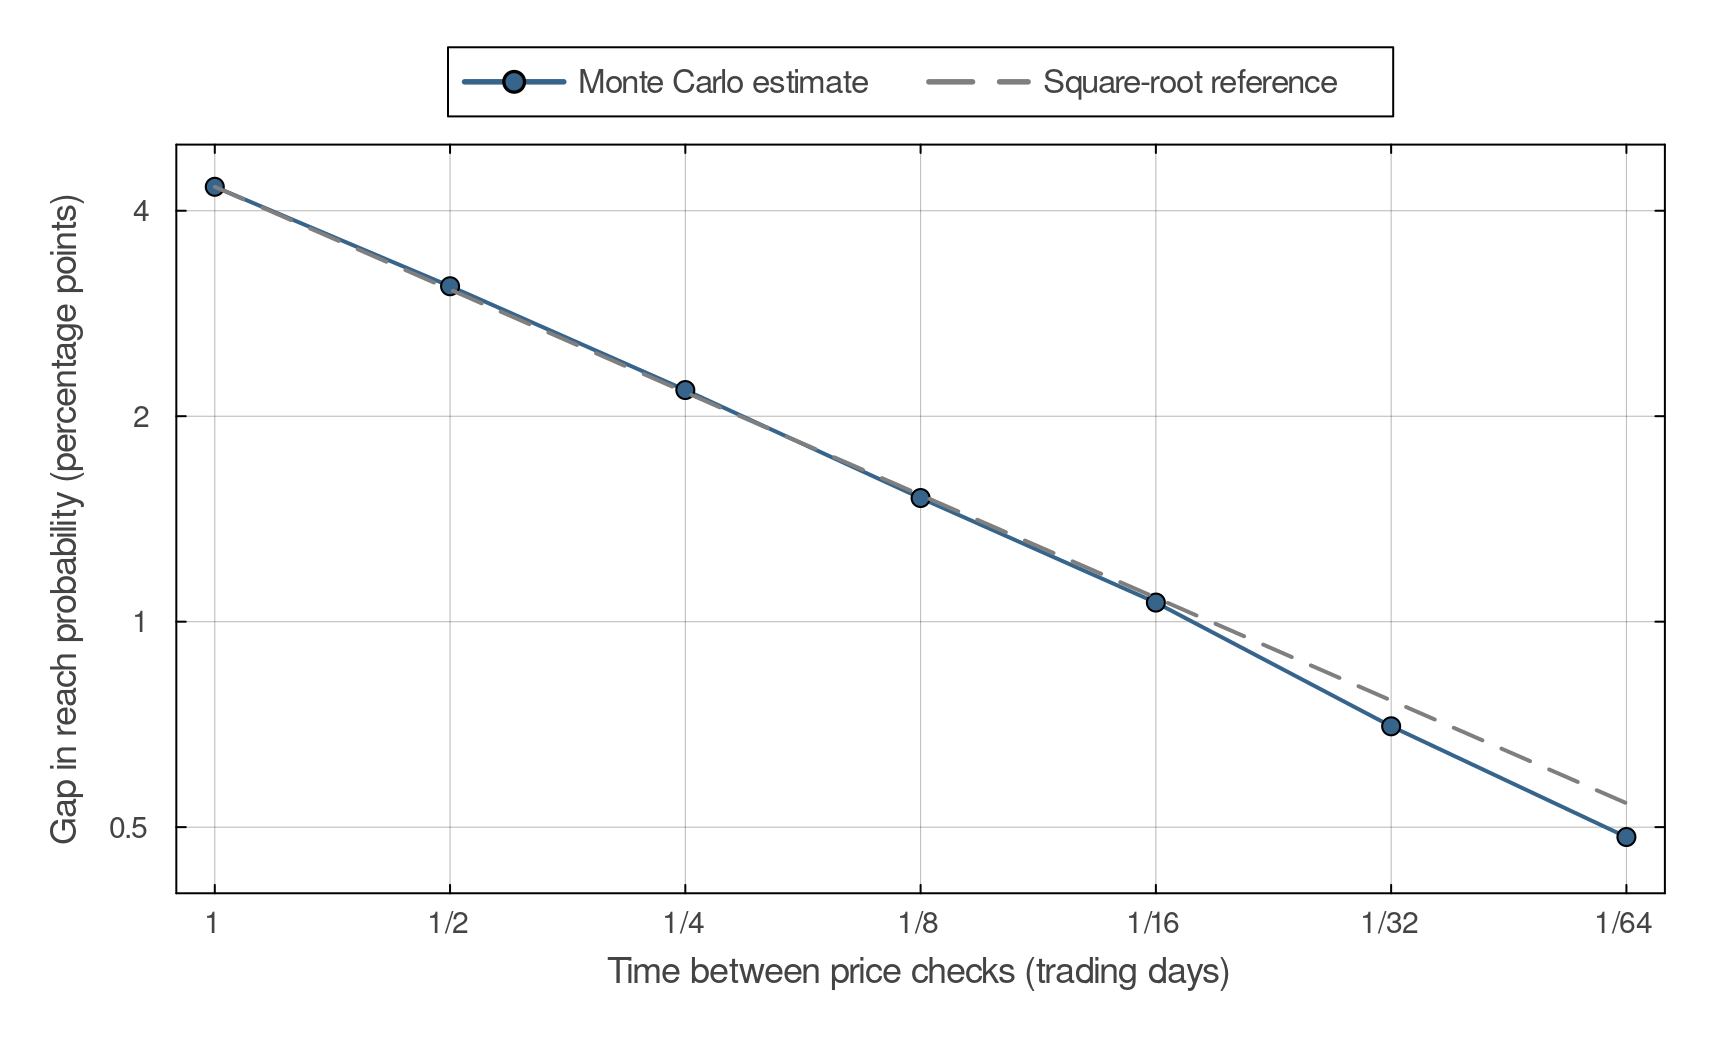

In [11]:
let
    Δt = monitoring_table.Δt # years between checks
    gap = monitoring_table.gap # continuous probability minus the simulated probability
    days_between_checks = 252 .* Δt # use the notebook's trading-year convention
    # Label all seven intervals for the default quarter-year monitoring schedules -
    interval_labels = ["1", "1/2", "1/4", "1/8", "1/16", "1/32", "1/64"]
    # Convert gaps to percentage points; finer monitoring appears to the right -
    plot(days_between_checks, 100 .* gap;
        xscale = :log10, yscale = :log10, xflip = true,
        marker = :circle, markersize = 5, color = :steelblue4,
        label = "Monte Carlo estimate",
        xlabel = "Time between price checks (trading days)",
        ylabel = "Gap in reach probability (percentage points)",
        size = (860, 520), dpi = 200, legend = :outertop, legend_column = 2,
        legendfontsize = 11, guidefontsize = 12, tickfontsize = 10,
        background_color = :white, gridalpha = 0.15,
        xticks = (days_between_checks, interval_labels),
        xlims = (minimum(days_between_checks)/1.12, maximum(days_between_checks)*1.12),
        yticks = ([0.5, 1.0, 2.0, 4.0], ["0.5", "1", "2", "4"]),
        ylims = (0.4, 5.0),
        left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 5Plots.mm, top_margin = 4Plots.mm)
    # Anchor the square-root reference at the daily-monitoring estimate -
    plot!(days_between_checks, 100 .* gap[1] .* sqrt.(Δt ./ Δt[1]);
        color = :gray50, linestyle = :dash, linewidth = 2,
        label = "Square-root reference")
end

For the illustrative parameters, daily monitoring gives a reach probability about 4.34 percentage points below the continuous result. The gap decreases roughly with the square root of the time between checks over the plotted range. The Monte Carlo uncertainty becomes more noticeable relative to the gap at the finest monitoring intervals, so the plotted estimates do not establish an exact convergence rate.

The shifted-boundary approximation lies within about 0.2 percentage points of the Monte Carlo estimates at the tested frequencies. Their standard errors are about 0.16 percentage points, so this agreement should be interpreted alongside the simulation uncertainty. Both the gap and the approximation's accuracy can change with the model parameters and take-profit price.

These calculations show why the monitoring schedule is part of the exit rule. A daily-check rule and a continuously monitored rule can have different exit probabilities even when they use the same take-profit price.

___


## Summary

We extended the L4a first-passage calculation to geometric Brownian motion, using analytical probabilities, a binomial lattice, and simulation to examine when a position exits.

> __Key Takeaways:__
>
> * **Probability of reaching a take-profit price:** We used the reflection-principle result to calculate the probability of reaching a take-profit price during the holding period. Separating paths that finish above the target from those that reach it and then fall below it explained why a final-price check can miss an earlier exit.
> * **Competing take-profit and stop-loss exits:** We carried forward only the probabilities of positions still open on a GBM-calibrated lattice and compared the results with simulated daily prices. This gave us the probabilities of each first exit and of still holding the shares, while distinguishing lattice approximation from Monte Carlo uncertainty.
> * **Effect of the monitoring schedule:** We compared increasingly frequent price checks with the continuous single-barrier probability and evaluated a shifted-boundary approximation. The results showed how observations between daily checks can detect additional exits and why we must state the monitoring schedule when reporting an exit probability.

Together, these calculations connect the chosen exit prices and monitoring schedule to the probabilities of selling or continuing to hold the shares.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

Barrier probabilities depend on the assumed parameters and on the stated monitoring and execution rules; a real stop or limit order need not execute at its trigger price.
